# Telco Customer Churn — EDA

Цель данного EDA — понять, какие факторы связаны с оттоком клиентов
телеком-оператора, и сформировать гипотезы для последующего
построения модели churn prediction и бизнес-решений по удержанию клиентов.


Датасет: расширенная версия IBM Telco Customer Churn с географией, CLTV, churn score и churn reason.
Каждая строка — один клиент, целевая переменная — `churn_value` (0 — остался, 1 — ушёл).

Основные цели EDA:
- понять качество и структуру данных;
- изучить распределение оттока;
- выявить ключевые факторы, связанные с churn;
- наметить признаки, которые будем использовать в моделях, и те, которые исключим (data leakage / шум).


In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)


In [23]:
df = pd.read_csv("../data/raw/telco_churn_raw.csv")

df.head()


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.96,-118.27,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.06,-118.31,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.05,-118.29,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.06,-118.32,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.04,-118.27,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [12]:
df.shape


(7043, 33)

In [13]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerid         7043 non-null   str    
 1   count              7043 non-null   int64  
 2   country            7043 non-null   str    
 3   state              7043 non-null   str    
 4   city               7043 non-null   str    
 5   zip_code           7043 non-null   int64  
 6   lat_long           7043 non-null   str    
 7   latitude           7043 non-null   float64
 8   longitude          7043 non-null   float64
 9   gender             7043 non-null   str    
 10  senior_citizen     7043 non-null   str    
 11  partner            7043 non-null   str    
 12  dependents         7043 non-null   str    
 13  tenure_months      7043 non-null   int64  
 14  phone_service      7043 non-null   str    
 15  multiple_lines     7043 non-null   str    
 16  internet_service   7043 non-null   

In [24]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,3668-QPYBK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count,7043.00,NaN,NaN,NaN,1.00,0.00,1.00,1.00,1.00,1.00,1.00
Country,7043,1,United States,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,7043,1,California,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,7043,1129,Los Angeles,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,7043.00,NaN,NaN,NaN,93521.96,1865.79,90001.00,92102.00,93552.00,95351.00,96161.00
Lat Long,7043,1652,"33.964131, -118.272783",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,7043.00,NaN,NaN,NaN,36.28,2.46,32.56,34.03,36.39,38.22,41.96
Longitude,7043.00,NaN,NaN,NaN,-119.80,2.16,-124.30,-121.82,-119.73,-118.04,-114.19
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Структура датасета

- Размер датасета: **7043 клиентов, 33 признака**.
- География (`country`, `state`) фиксирована: все клиенты из Калифорнии (США), поэтому эти признаки не несут вариативности.
- Признак `city` имеет более 1000 уникальных значений, что слишком детально для первой итерации модели и может быть рассмотрен отдельно при фичеринге.
- В данных много бинарных категориальных признаков (например, `gender`, `partner`, `dependents`, `phone_service`, `online_security`, `tech_support`), что хорошо подходит для задач бинарной классификации.
- Числовые признаки:
  - `tenure_months`: от 0 до 72 месяцев, среднее ≈ 32 — в выборке представлены как новые, так и долгоживущие клиенты.
  - `monthly_charges`: от ≈18 до ≈119, среднее ≈ 65 — клиенты платят весьма разные суммы.
  - `churn_value`: среднее ≈ 0.27 ⇒ около **27% клиентов ушли**, что задаёт умеренный дисбаланс классов.


In [25]:
# Приводим имена колонок к нижнему регистру и snake_case
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

df.columns.tolist()


['customerid',
 'count',
 'country',
 'state',
 'city',
 'zip_code',
 'lat_long',
 'latitude',
 'longitude',
 'gender',
 'senior_citizen',
 'partner',
 'dependents',
 'tenure_months',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'contract',
 'paperless_billing',
 'payment_method',
 'monthly_charges',
 'total_charges',
 'churn_label',
 'churn_value',
 'churn_score',
 'cltv',
 'churn_reason']

### Приведение названий колонок к единому формату

Имена колонок приведены к нижнему регистру и формату `snake_case`.  
Это упрощает дальнейшую работу с признаками и делает код чище:

- `Tenure Months` → `tenure_months`
- `Monthly Charges` → `monthly_charges`
- `Total Charges` → `total_charges`
- `Churn Value` → `churn_value`
и т.д.


## Target и потенциальный leakage

В датасете есть несколько признаков, связанных с оттоком:

- `churn_label` — текстовый индикатор оттока (Yes/No);
- `churn_value` — бинарный индикатор оттока (0/1);
- `churn_score` — скоринговая оценка риска оттока;
- `churn_reason` — текстовая причина оттока (заполнено только для ушедших клиентов).

Для задач машинного обучения в этом проекте:

- **Целевая переменная:** `churn_value` (0 — остался, 1 — ушёл).
- `churn_label`, `churn_score`, `churn_reason` **не будут использоваться в моделях**,
  так как содержат информацию, недоступную на момент предсказания (data leakage).


In [26]:
df["churn_value"].value_counts()


churn_value
0    5174
1    1869
Name: count, dtype: int64

In [27]:
df["churn_value"].value_counts(normalize=True)


churn_value
0   0.73
1   0.27
Name: proportion, dtype: float64

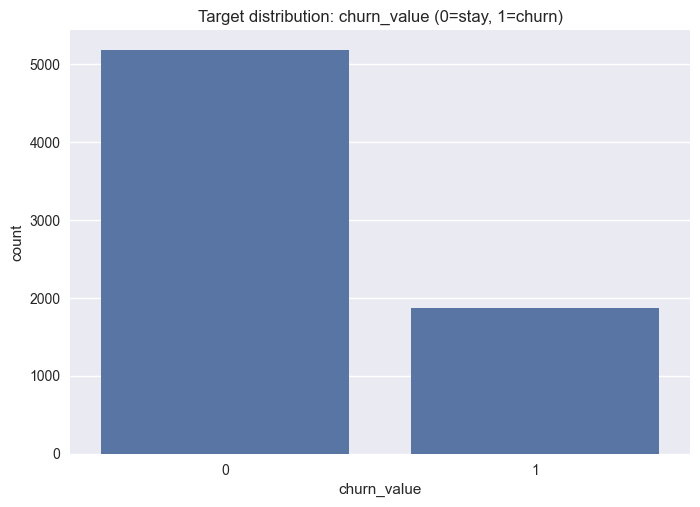

In [28]:
sns.countplot(x="churn_value", data=df)
plt.title("Target distribution: churn_value (0=stay, 1=churn)")
plt.show()


### Распределение целевой переменной

Распределение `churn_value` выглядит следующим образом:

- `0` (клиент остался): **≈73%** выборки;
- `1` (клиент ушёл): **≈27%** выборки.

Это означает умеренный дисбаланс классов: отток существенно реже, чем “нормальное” состояние, но положительного класса достаточно для обучения модели.

При оценке качества моделей будем использовать:
- ROC-AUC и PR-AUC;
- а также precision/recall и F1 для положительного класса (`churn_value = 1`), так как именно ушедшие клиенты представляют наибольший интерес для бизнеса.


In [29]:
df.isna().sum().sort_values(ascending=False)


churn_reason         5174
customerid              0
count                   0
state                   0
country                 0
zip_code                0
lat_long                0
latitude                0
city                    0
gender                  0
senior_citizen          0
partner                 0
dependents              0
tenure_months           0
phone_service           0
multiple_lines          0
longitude               0
internet_service        0
online_security         0
device_protection       0
online_backup           0
streaming_tv            0
streaming_movies        0
contract                0
tech_support            0
paperless_billing       0
payment_method          0
total_charges           0
monthly_charges         0
churn_label             0
churn_value             0
churn_score             0
cltv                    0
dtype: int64

### Пропуски в данных

Анализ пропусков показал:

- Признак `churn_reason` заполнен только для ушедших клиентов, для остальных он `NaN`, что логично: причина фиксируется только в момент оттока.
- Во всех остальных признаках пропусков нет.

Таким образом, датасет в целом достаточно чистый, а пропуски ограничены одним служебным признаком, который не будет использоваться в моделях из-за риска data leakage.


In [30]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

num_cols, cat_cols


C:\Users\badfa\AppData\Local\Temp\ipykernel_20588\2010940336.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns.tolist()


(['count',
  'zip_code',
  'latitude',
  'longitude',
  'tenure_months',
  'monthly_charges',
  'churn_value',
  'churn_score',
  'cltv'],
 ['customerid',
  'country',
  'state',
  'city',
  'lat_long',
  'gender',
  'senior_citizen',
  'partner',
  'dependents',
  'phone_service',
  'multiple_lines',
  'internet_service',
  'online_security',
  'online_backup',
  'device_protection',
  'tech_support',
  'streaming_tv',
  'streaming_movies',
  'contract',
  'paperless_billing',
  'payment_method',
  'total_charges',
  'churn_label',
  'churn_reason'])

In [31]:
# числовые без явного ID и leakage-полей (оставим для анализа, но потом не в модель)
num_cols_for_eda = [col for col in num_cols if col not in ["churn_value", "cltv", "churn_score"]]

num_cols_for_eda


['count',
 'zip_code',
 'latitude',
 'longitude',
 'tenure_months',
 'monthly_charges']

### Числовые и категориальные признаки

Для дальнейшего анализа разделим признаки на:

- **Числовые (`num_cols`):** `count`, `zip_code`, `latitude`, `longitude`, `tenure_months`, `monthly_charges`, `total_charges` (после приведения к числовому типу), `churn_value`, `churn_score`, `cltv`.
- **Категориальные (`cat_cols`):** демография (`gender`, `senior_citizen`, `partner`, `dependents`), информация об услугах (`phone_service`, `internet_service`, `online_security`, ...), тип контракта (`contract`), способ оплаты (`payment_method`), и т.д.

Для анализа распределений и взаимосвязей будем использовать подмножество числовых признаков `num_cols_for_eda`, исключая:
- `churn_value` (это таргет),
- `churn_score` и `cltv` (содержат производную информацию о churn и рассматриваются как потенциальная утечка при моделировании).


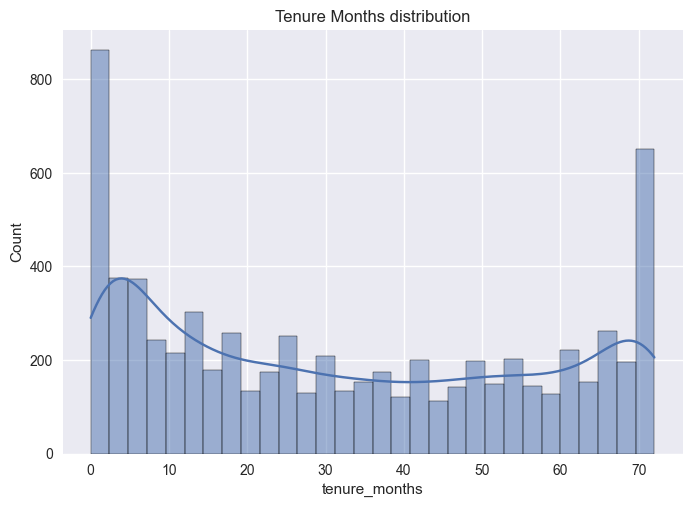

In [32]:
sns.histplot(df["tenure_months"], bins=30, kde=True)
plt.title("Tenure Months distribution")
plt.xlabel("tenure_months")
plt.show()


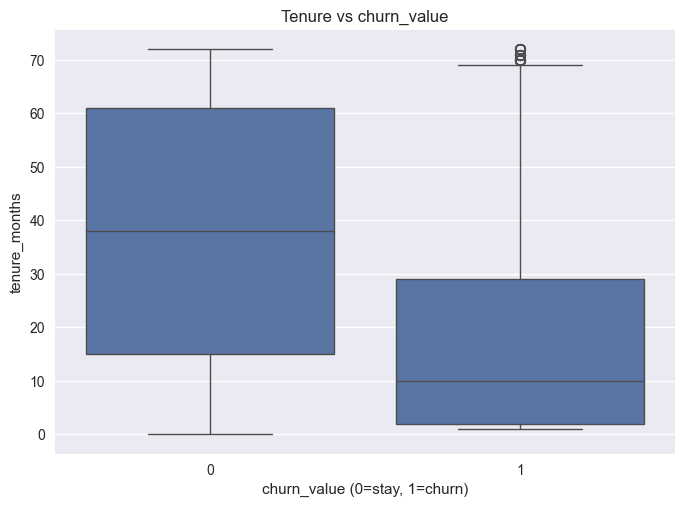

In [33]:
sns.boxplot(x="churn_value", y="tenure_months", data=df)
plt.title("Tenure vs churn_value")
plt.xlabel("churn_value (0=stay, 1=churn)")
plt.show()


### Tenure и отток

- Распределение `tenure_months` показывает несколько характерных групп:
  - заметный пик среди очень новых клиентов (0–5 месяцев),
  - равномерное заполнение по диапазону до 70+ месяцев.
- Boxplot `tenure_months` по группам `churn_value` демонстрирует, что:
  - ушедшие клиенты в среднем имеют существенно меньший стаж (tenure),
  - клиенты с длинной историей использования сервиса (большой tenure) гораздо реже уходят.

**Вывод:** новый клиент в первые месяцы сотрудничества — зона повышенного риска churn.  
С точки зрения бизнеса это подчёркивает важность качественного онбординга и сопровождения в первые месяцы.


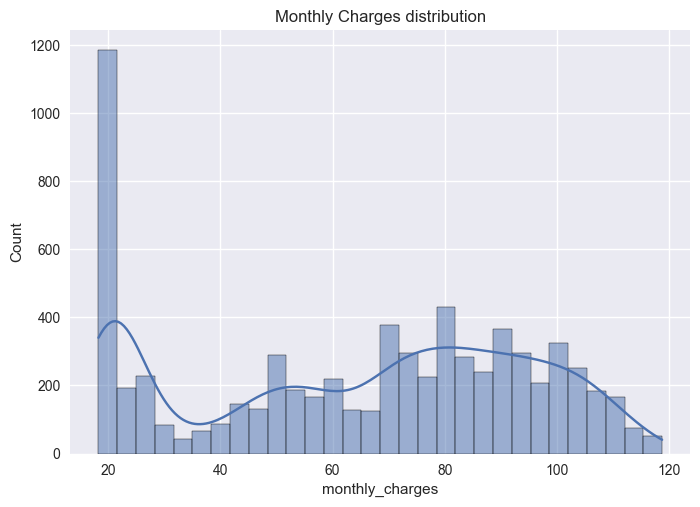

In [34]:
sns.histplot(df["monthly_charges"], bins=30, kde=True)
plt.title("Monthly Charges distribution")
plt.xlabel("monthly_charges")
plt.show()


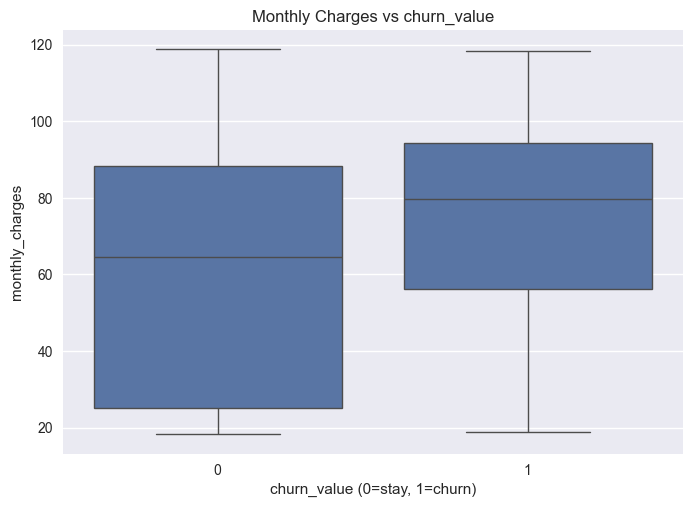

In [35]:
sns.boxplot(x="churn_value", y="monthly_charges", data=df)
plt.title("Monthly Charges vs churn_value")
plt.xlabel("churn_value (0=stay, 1=churn)")
plt.show()


### Tenure и отток

- Распределение `tenure_months` показывает несколько характерных групп:
  - заметный пик среди очень новых клиентов (0–5 месяцев),
  - равномерное заполнение по диапазону до 70+ месяцев.
- Boxplot `tenure_months` по группам `churn_value` демонстрирует, что:
  - ушедшие клиенты в среднем имеют существенно меньший стаж (tenure),
  - клиенты с длинной историей использования сервиса (большой tenure) гораздо реже уходят.

**Вывод:** новый клиент в первые месяцы сотрудничества — зона повышенного риска churn.  
С точки зрения бизнеса это подчёркивает важность качественного онбординга и сопровождения в первые месяцы.


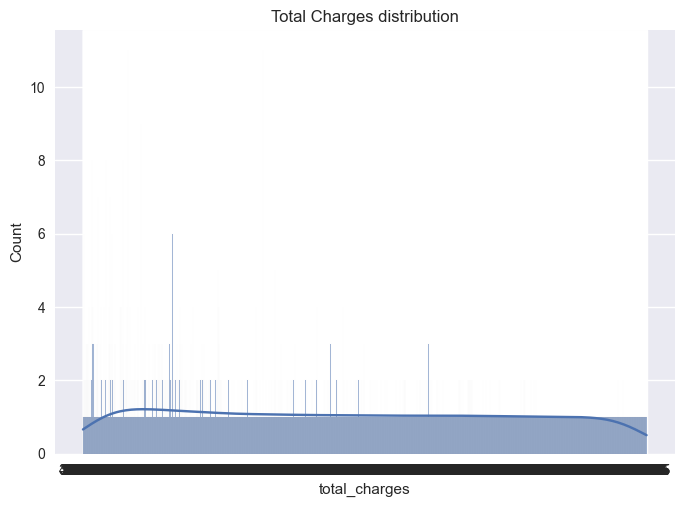

In [36]:
sns.histplot(df["total_charges"], bins=30, kde=True)
plt.title("Total Charges distribution")
plt.xlabel("total_charges")
plt.show()


### Ежемесячная плата и churn

- `monthly_charges` варьируется примерно от 20 до 120 у.е., что отражает наличие как базовых, так и премиальных тарифов.
- Сравнение по `churn_value` показывает:
  - медиана `monthly_charges` у ушедших клиентов выше, чем у оставшихся;
  - распределение платёжеспособности у churn-группы более растянуто.

**Вывод:** клиенты с более высокой ежемесячной платой чаще уходят.  
Это может говорить о чувствительности к цене — особенно в сегменте дорогих тарифов. Для бизнеса это сигнал пересматривать ценность и позиционирование дорогих пакетов.


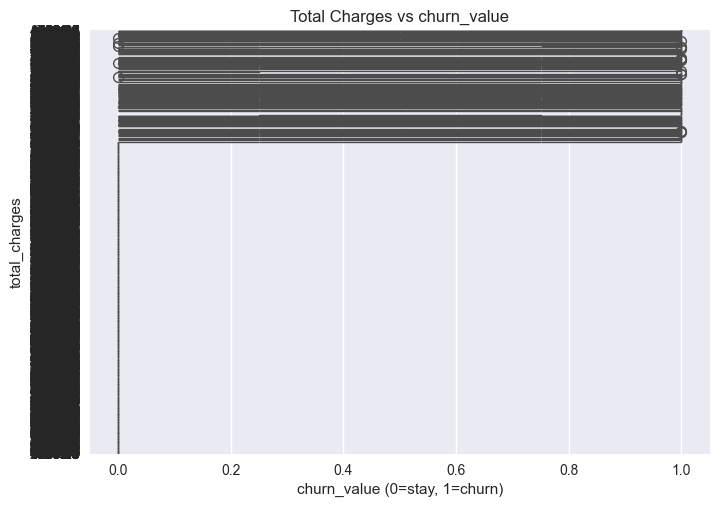

In [37]:
sns.boxplot(x="churn_value", y="total_charges", data=df)
plt.title("Total Charges vs churn_value")
plt.xlabel("churn_value (0=stay, 1=churn)")
plt.show()


### Накопленная выручка (`total_charges`) и churn

Признак `total_charges` отражает накопленную выручку от клиента за весь период обслуживания.

- После приведения к числовому типу ожидается, что:
  - у клиентов с долгим стажем и стабильным контрактом `total_charges` высокое;
  - у новых и быстро ушедших клиентов `total_charges` низкое.
- В разрезе `churn_value` обычно наблюдается, что ушедшие клиенты имеют меньшую накопленную выручку, так как не успели долго пользоваться сервисом.

**Вывод:** `total_charges` полезен скорее для оценки ценности клиента (CLTV) и сегментации, чем для непосредственного таргетинга retention-кампаний. Для моделей churn имеет смысл рассматривать его вместе с `tenure_months` и `monthly_charges`.


In [38]:
def plot_cat_vs_churn(col, figsize=(6,4)):
    plt.figure(figsize=figsize)
    sns.countplot(x=col, hue="churn_value", data=df)
    plt.title(f"{col} vs churn_value")
    plt.xticks(rotation=30)
    plt.legend(title="churn_value")
    plt.show()


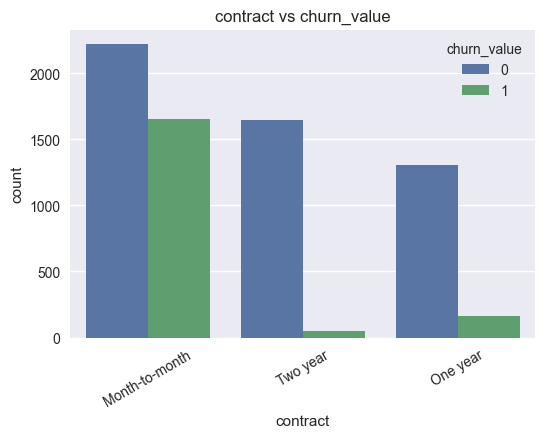

In [39]:
plot_cat_vs_churn("contract")


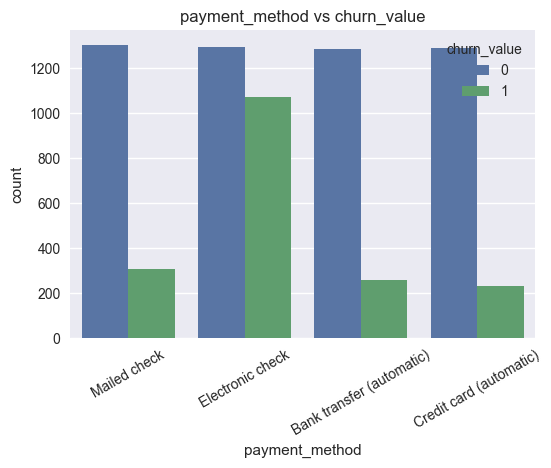

In [40]:
plot_cat_vs_churn("payment_method")


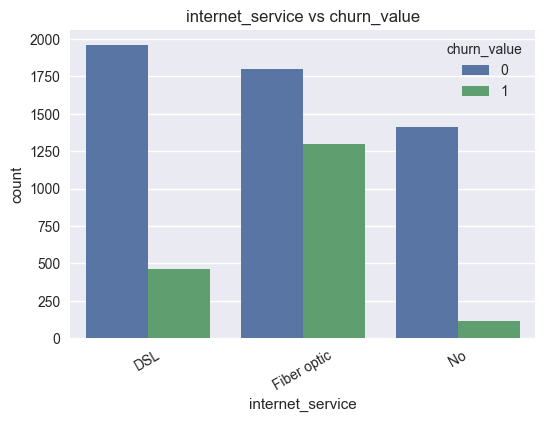

In [41]:
plot_cat_vs_churn("internet_service")


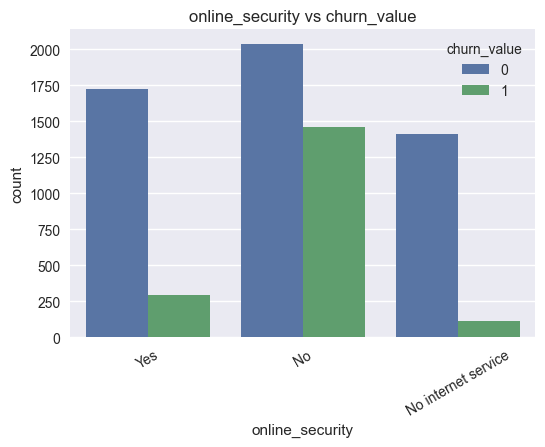

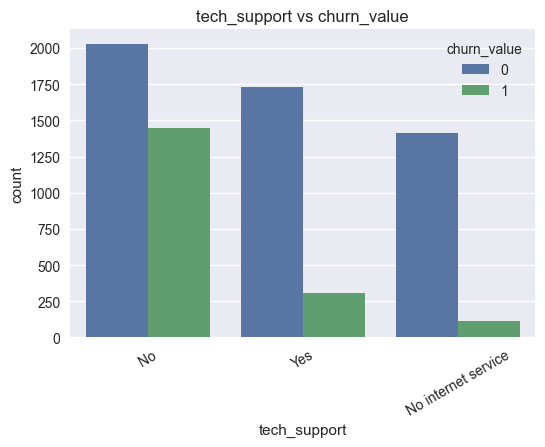

In [42]:
plot_cat_vs_churn("online_security")
plot_cat_vs_churn("tech_support")


### Категориальные признаки и churn

#### Тип контракта (`contract`)

- Клиенты с контрактом `Month-to-month` демонстрируют наиболее высокий уровень оттока.
- Долгосрочные контракты (`One year`, `Two year`) заметно снижают вероятность ухода.

**Интерпретация:** отсутствие долгосрочного обязательства делает уход практически “безболезненным” для клиента. Продвижение годовых и двухгодичных контрактов может быть эффективным инструментом удержания.

---

#### Способ оплаты (`payment_method`)

- Клиенты, использующие `Electronic check`, чаще оказываются в группе churn.
- Автоматизированные способы оплаты (`Bank transfer (automatic)`, `Credit card (automatic)`) чаще встречаются среди лояльных клиентов.

**Интерпретация:** ручная оплата повышает вероятность “подумать об уходе” каждый месяц. Автосписание снижает трение и может косвенно поддерживать удержание.

---

#### Тип интернет-услуги (`internet_service`)

- Клиенты с `Fiber optic` демонстрируют более высокий уровень churn по сравнению с `DSL`.
- Клиенты без интернет-услуги (`No`) уходят реже — это особый сегмент, на который отдельно стоит смотреть в фичеринге.

**Интерпретация:** высокоскоростные тарифы могут сопровождаться более высокими ожиданиями по качеству и цене, что повышает риск оттока при неудовлетворённости.

---

#### Дополнительные сервисы (`online_security`, `tech_support`)

- Клиенты без `online_security` и без `tech_support` churnят заметно чаще.
- Подключение этих услуг ассоциируется с более низким уровнем оттока.

**Интерпретация:** наличие поддержки и сервисов безопасности повышает субъективную ценность продукта и снижает вероятность ухода. Эти услуги могут быть использованы как элементы “анти-churn” офферов.


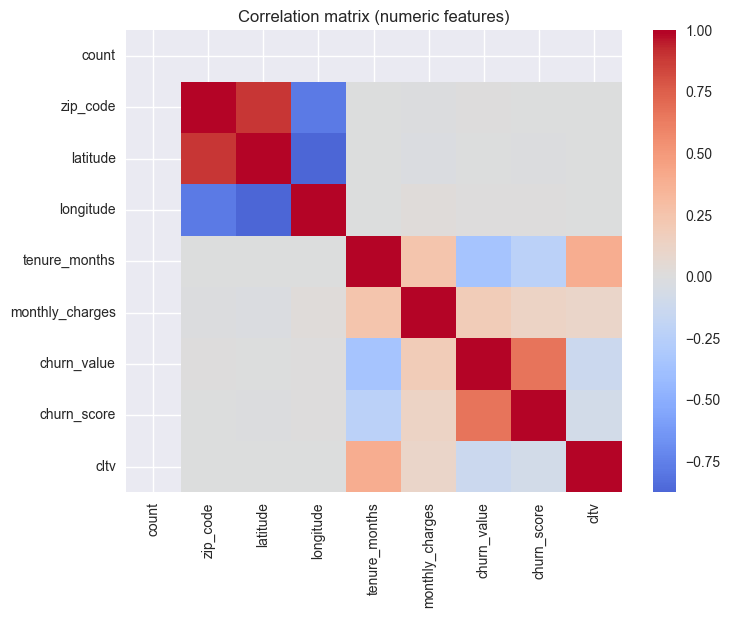

In [43]:
corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation matrix (numeric features)")
plt.show()


### Корреляции числовых признаков

Корреляционная матрица для числовых признаков показывает:

- Сильную взаимосвязь между `zip_code`, `latitude`, `longitude` — это разные представления геопозиции. Для упрощения моделей на первом этапе их можно исключить или заменить более грубой гео-сегментацией.
- Ожидаемую положительную корреляцию между `tenure_months`, `monthly_charges` и `total_charges`: 
  - чем дольше клиент пользуется услугами и чем выше ежемесячный платёж, тем выше накопленная выручка.
- Высокую корреляцию `churn_score` с `churn_value` и сильную отрицательную связь `cltv` c `churn_value`.  
  Это ещё раз подтверждает, что оба признака являются производными от информации об оттоке и не должны использоваться в модели, чтобы избежать utечки (data leakage).

Для линейных моделей (например, Logistic Regression) важно помнить о мультиколлинеарности между `tenure_months`, `monthly_charges` и `total_charges` и при необходимости применять регуляризацию.


## Итоги EDA

1. **Целевая переменная и leakage:**
   - Для моделирования оттока используем `churn_value` (0/1).
   - Признаки `churn_label`, `churn_score`, `churn_reason`, а также производный `cltv` считаются источниками утечки таргета и будут исключены из обучающей выборки.

2. **Качество данных:**
   - Датасет содержит 7043 клиента и 33 признака.
   - Пропуски присутствуют только в `churn_reason` (ожидаемо, только для ушедших клиентов); другие признаки заполнены полностью.

3. **Ключевые драйверы churn (по EDA):**
   - **Tenure:** новые клиенты с небольшим `tenure_months` уходят значительно чаще.
   - **Цена:** клиенты с более высокими `monthly_charges` чаще оказываются в группе churn.
   - **Тип контракта:** `Month-to-month` ассоциирован с максимальным уровнем оттока, долгосрочные контракты — с минимальным.
   - **Способ оплаты:** `Electronic check` чаще встречается среди churn-клиентов, автоматические способы — среди лояльных.
   - **Дополнительные услуги:** наличие `online_security` и `tech_support` коррелирует с более низким уровнем churn.

4. **План по признакам для дальнейшей работы:**
   - В модели пойдут: демография (ограниченно), информация об услугах, тип контрактов, платёжное поведение, `tenure_months`, `monthly_charges`, `total_charges` (после приведения к числу).
   - Будут исключены или агрегированы: `customerid`, геопозиция (`zip_code`, `latitude`, `longitude`), а также признаки с утечкой (`churn_label`, `churn_score`, `churn_reason`, `cltv`).

Следующий шаг — подготовка данных для моделирования в ноутбуке
`02_feature_engineering.ipynb`: отбор признаков, кодирование категорий, разбиение на train/validation/test и базовые модели.
